# Import Library

In [3]:
import pandas as pd  # Pandas untuk manipulasi dan analisis data
pd.options.mode.chained_assignment = None  # Menonaktifkan peringatan chaining
import numpy as np  # NumPy untuk komputasi numerik
seed = 0
np.random.seed(seed)  # Mengatur seed untuk reproduktibilitas
import matplotlib.pyplot as plt  # Matplotlib untuk visualisasi data
import seaborn as sns  # Seaborn untuk visualisasi data statistik, mengatur gaya visualisasi

import datetime as dt  # Manipulasi data waktu dan tanggal
import re  # Modul untuk bekerja dengan ekspresi reguler
import string  # Berisi konstanta string, seperti tanda baca
from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks

!pip install sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia

from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks

import nltk  # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
app_reviews_df = pd.read_csv('ulasan_aplikasi.csv')
app_reviews_df.shape
app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,0321d976-0cc8-4143-9f05-7574651dab78,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"knp ya akhir"" ini Qris BCA susah di akses. loa...",4,0,4.7.9,2026-03-30 05:08:15,Mohon maaf atas kendala yang Bapak/Ibu alami. ...,2026-03-30 05:25:34,4.7.9
1,a292b0aa-418a-400f-89b2-1672154c2d61,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"kenapa kok sering merah indikator nya , dan it...",1,0,4.7.9,2026-03-30 04:59:48,Mohon maaf atas kendala yang Bapak/Ibu alami. ...,2026-03-30 05:27:50,4.7.9
2,3a6844b6-5006-4cb6-9a8a-a90a8de96669,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"apk nya ngeleg""",1,0,NaN,2026-03-30 04:50:10,Mohon maaf atas kendala yang Bapak/Ibu alami. ...,2026-03-30 05:25:15,NaN
3,6dfba802-7d06-4830-ab15-40dcec38e467,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mudah bgt & aman,5,0,4.7.9,2026-03-30 04:29:42,Terima kasih atas ulasannya. Semoga aplikasi B...,2026-03-30 04:32:25,4.7.9
4,f5ceab55-2680-429d-825c-29ceb00955d8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ok,5,0,4.7.9,2026-03-30 04:05:55,Terima kasih atas ulasannya. Semoga aplikasi B...,2026-03-30 04:32:22,4.7.9


In [5]:
app_reviews_df = pd.read_csv('ulasan_aplikasi.csv')
jumlah_ulasan, jumlah_kolom = app_reviews_df.shape

In [6]:
app_reviews_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,0321d976-0cc8-4143-9f05-7574651dab78,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"knp ya akhir"" ini Qris BCA susah di akses. loa...",4,0,4.7.9,2026-03-30 05:08:15,Mohon maaf atas kendala yang Bapak/Ibu alami. ...,2026-03-30 05:25:34,4.7.9
1,a292b0aa-418a-400f-89b2-1672154c2d61,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"kenapa kok sering merah indikator nya , dan it...",1,0,4.7.9,2026-03-30 04:59:48,Mohon maaf atas kendala yang Bapak/Ibu alami. ...,2026-03-30 05:27:50,4.7.9
2,3a6844b6-5006-4cb6-9a8a-a90a8de96669,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"apk nya ngeleg""",1,0,NaN,2026-03-30 04:50:10,Mohon maaf atas kendala yang Bapak/Ibu alami. ...,2026-03-30 05:25:15,NaN
3,6dfba802-7d06-4830-ab15-40dcec38e467,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mudah bgt & aman,5,0,4.7.9,2026-03-30 04:29:42,Terima kasih atas ulasannya. Semoga aplikasi B...,2026-03-30 04:32:25,4.7.9
4,f5ceab55-2680-429d-825c-29ceb00955d8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ok,5,0,4.7.9,2026-03-30 04:05:55,Terima kasih atas ulasannya. Semoga aplikasi B...,2026-03-30 04:32:22,4.7.9


In [7]:
app_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              15000 non-null  object
 1   userName              15000 non-null  object
 2   userImage             15000 non-null  object
 3   content               15000 non-null  object
 4   score                 15000 non-null  int64 
 5   thumbsUpCount         15000 non-null  int64 
 6   reviewCreatedVersion  11800 non-null  object
 7   at                    15000 non-null  object
 8   replyContent          15000 non-null  object
 9   repliedAt             15000 non-null  object
 10  appVersion            11800 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.3+ MB


In [8]:
clean_df = app_reviews_df.dropna()

In [9]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11800 entries, 0 to 14999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              11800 non-null  object
 1   userName              11800 non-null  object
 2   userImage             11800 non-null  object
 3   content               11800 non-null  object
 4   score                 11800 non-null  int64 
 5   thumbsUpCount         11800 non-null  int64 
 6   reviewCreatedVersion  11800 non-null  object
 7   at                    11800 non-null  object
 8   replyContent          11800 non-null  object
 9   repliedAt             11800 non-null  object
 10  appVersion            11800 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.1+ MB


In [10]:
# Menghapus baris duplikat dari DataFrame clean_df
clean_df = clean_df.drop_duplicates()

# Menghitung jumlah baris dan kolom dalam DataFrame clean_df setelah menghapus duplikat
jumlah_ulasan_setelah_hapus_duplikat, jumlah_kolom_setelah_hapus_duplikat = clean_df.shape

In [11]:
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka

    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text

def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text

def filteringText(text): # Menghapus stopwords dalam teks
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya', 'yaa', 'nya', 'na', 'sih', 'ku', 'di', 'ya', 'loh', 'kah', 'woi', 'woii', 'woy', 'aja',
                          'udah', 'udh', 'terus', 'pas', 'deh', 'dong', 'nih', 'tuh', 'nihh', 'tuhh', 'doang', 'saja',
                          'lah', 'tah', 'kan', 'pun', 'kok', 'eh', 'hmm'])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text): # Mengurangi kata ke bentuk dasarnya yang menghilangkan imbuhan awalan dan akhiran atau ke akar kata
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    # Memecah teks menjadi daftar kata
    words = text.split()

    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]

    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

In [12]:
# NOTE: slangwords dan stopwords hasil generate claude dari data hasil EDA
slangwords = {
    'gak':'tidak','ga':'tidak','ngak':'tidak','nggak':'tidak','gk':'tidak','tdk':'tidak',
    'ga bisa':'tidak bisa','gamau':'tidak mau','gabisa':'tidak bisa',

    'udah':'sudah','udh':'sudah','dah':'sudah','sdh':'sudah','uda':'sudah',
    'blm':'belum','blom':'belum','belom':'belum',

    'bgt':'sangat','bngt':'sangat','banget':'sangat','bener bener':'sungguh',
    'mantap':'bagus','mantul':'bagus','keren':'bagus','ok':'bagus','oke':'bagus',
    'okelah':'bagus','ok lah':'bagus','top':'bagus','jos':'bagus',
    'josss':'bagus','joss':'bagus','asyik':'bagus','asik':'bagus',
    'sip':'bagus','sippp':'bagus','sippp':'bagus','kece':'bagus',
    'ciamik':'bagus','canggih':'bagus','kinclong':'bagus',
    'lancar':'lancar','cepat':'cepat','mudah':'mudah','gampang':'mudah',

    'lelet':'lambat','lemot':'lambat','lambat':'lambat',
    'ribet':'rumit','ruwet':'rumit','susah':'sulit','susah':'sulit',
    'eror':'error','err':'error','hang':'error','ngehang':'error',
    'bug':'error','bugg':'error','buggy':'error',
    'parah':'buruk','paling parah':'sangat buruk','jelek':'buruk',
    'jelekk':'buruk','ancur':'buruk','amburadul':'buruk',
    'zonk':'buruk','zonkk':'buruk','kacau':'buruk',
    'ngecewain':'mengecewakan','nyebelin':'menjengkelkan',
    'nyusahin':'menyusahkan','ngeselin':'menjengkelkan',
    'ganggu':'mengganggu','ngganggu':'mengganggu',

    'maks':'maksimal','lbh':'lebih',
    'bener':'benar','bnr':'benar','beneran':'benar',
    'emg':'memang','emang':'memang','mmg':'memang',
    'kyk':'seperti','kyak':'seperti',
    'gini':'begini','gitu':'begitu',
    'tp':'tapi','tpi':'tapi',
    'kl':'kalau','klo':'kalau','klu':'kalau','kalo':'kalau',
    'krn':'karena','karna':'karena','krna':'karena',
    'pdhl':'padahal','pdhal':'padahal',
    'jg':'juga','trs':'terus','trus':'terus',
    'aja':'saja','aj':'saja','doang':'saja',
    'nih':'ini','ni':'ini','tu':'itu','tuh':'itu',
    'gw':'saya','gue':'saya','w':'saya',
    'lo':'kamu','lu':'kamu','elu':'kamu',
    'bs':'bisa','dr':'dari','utk':'untuk','tuk':'untuk',
    'dgn':'dengan','dg':'dengan','yg':'yang',
    'sm':'sama','ama':'sama','lg':'lagi','lgi':'lagi',
    'dpt':'dapat','dpat':'dapat','hrs':'harus',
    'mkn':'mungkin','mgkn':'mungkin','mo':'mau',
    'dtg':'datang','pake':'pakai','make':'pakai',
    'balikin':'kembalikan','benerin':'perbaiki','beresin':'perbaiki',
    'makin':'semakin','tau':'tahu','taw':'tahu',
    'knp':'kenapa','knpa':'kenapa',
    'cuma':'hanya','cm':'hanya','cmn':'hanya',
    'kmrn':'kemarin','skrg':'sekarang','skrng':'sekarang',
    'sbnrnya':'sebenarnya','sebenernya':'sebenarnya',
    'makasih':'terima kasih','thx':'terima kasih','tks':'terima kasih',
    'notif':'notifikasi','trf':'transfer',

    'm-banking':'mobile banking','mbanking':'mobile banking',
    'inet':'internet','inet banking':'internet banking',
    'atm':'atm','wd':'tarik tunai','topup':'isi saldo',
    'login':'masuk','logout':'keluar','log in':'masuk',
    'reload':'muat ulang','refresh':'segarkan',
    'transaksi':'transaksi','verif':'verifikasi','otp':'kode otp'}

def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [13]:
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

In [14]:
clean_df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,0321d976-0cc8-4143-9f05-7574651dab78,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"knp ya akhir"" ini Qris BCA susah di akses. loa...",4,0,4.7.9,2026-03-30 05:08:15,Mohon maaf atas kendala yang Bapak/Ibu alami. ...,2026-03-30 05:25:34,4.7.9,knp ya akhir ini Qris BCA susah di akses loadi...,knp ya akhir ini qris bca susah di akses loadi...,kenapa ya akhir ini qris bca sulit di akses lo...,"[kenapa, ya, akhir, ini, qris, bca, sulit, di,...","[qris, bca, sulit, akses, loading, muncul, bar...",qris bca sulit akses loading muncul barcode aj...
1,a292b0aa-418a-400f-89b2-1672154c2d61,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"kenapa kok sering merah indikator nya , dan it...",1,0,4.7.9,2026-03-30 04:59:48,Mohon maaf atas kendala yang Bapak/Ibu alami. ...,2026-03-30 05:27:50,4.7.9,kenapa kok sering merah indikator nya dan itu...,kenapa kok sering merah indikator nya dan itu...,kenapa kok sering merah indikator nya dan itu ...,"[kenapa, kok, sering, merah, indikator, nya, d...","[merah, indikator, jd, transaksi, restajuga, b...",merah indikator jd transaksi restajuga bayar q...
3,6dfba802-7d06-4830-ab15-40dcec38e467,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mudah bgt & aman,5,0,4.7.9,2026-03-30 04:29:42,Terima kasih atas ulasannya. Semoga aplikasi B...,2026-03-30 04:32:25,4.7.9,mudah bgt aman,mudah bgt aman,mudah sangat aman,"[mudah, sangat, aman]","[mudah, aman]",mudah aman
4,f5ceab55-2680-429d-825c-29ceb00955d8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,ok,5,0,4.7.9,2026-03-30 04:05:55,Terima kasih atas ulasannya. Semoga aplikasi B...,2026-03-30 04:32:22,4.7.9,ok,ok,bagus,[bagus],[bagus],bagus
5,033666f8-ff82-447a-b841-8295aee6325b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat mendukung untuk bertransaksi dan meliha...,5,0,4.7.9,2026-03-30 03:39:12,Terima kasih atas ulasannya. Semoga aplikasi B...,2026-03-30 04:32:16,4.7.9,sangat mendukung untuk bertransaksi dan meliha...,sangat mendukung untuk bertransaksi dan meliha...,sangat mendukung untuk bertransaksi dan meliha...,"[sangat, mendukung, untuk, bertransaksi, dan, ...","[mendukung, bertransaksi, mutasi]",mendukung bertransaksi mutasi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14993,26d8a065-5e4f-44c6-825b-ae1658bc44c4,siraj sidqy,https://play-lh.googleusercontent.com/a/ACg8oc...,makin mudàh digunakan utk bertransaksi,5,0,4.6.4,2025-04-23 15:28:14,Terima kasih atas ulasannya. Semoga aplikasi B...,2025-04-23 15:35:15,4.6.4,makin mudàh digunakan utk bertransaksi,makin mudàh digunakan utk bertransaksi,semakin mudàh digunakan untuk bertransaksi,"[semakin, mudàh, digunakan, untuk, bertransaksi]","[mudàh, bertransaksi]",mudàh bertransaksi
14994,b8136ed2-9585-4aca-a627-c41bbc6c6cf8,Ay Buble,https://play-lh.googleusercontent.com/a/ACg8oc...,Baik baik saja,5,0,4.6.4,2025-04-23 15:26:18,Terima kasih atas ulasannya. Semoga aplikasi B...,2025-04-23 15:35:11,4.6.4,Baik baik saja,baik baik saja,baik baik saja,"[baik, baik, saja]",[],
14995,954ef9c5-9fce-4383-9aea-8db522dcfd13,okky priharmoko,https://play-lh.googleusercontent.com/a-/ALV-U...,keren,5,0,4.6.4,2025-04-23 15:22:50,Terima kasih atas ulasannya. Semoga aplikasi B...,2025-04-23 15:35:11,4.6.4,keren,keren,bagus,[bagus],[bagus],bagus
14998,7d5be895-674e-49a0-87cf-6525d403f199,Joss Andu,https://play-lh.googleusercontent.com/a/ACg8oc...,Ok,5,0,4.6.1,2025-04-23 15:19:27,Thank you for the review. Hopefully the BCA mo...,2025-04-23 15:34:53,4.6.1,Ok,ok,bagus,[bagus],[bagus],bagus


In [15]:
import csv
import requests
from io import StringIO

# Loads positive lexicon data from GitHub
# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")

# Loads negative lexicon data from GitHub
# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub

if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma

    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya ke dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [16]:
def sentiment_analysis_lexicon_indonesia(text):
    score = 0
    for word in text:
        if (word in lexicon_positive):
            score = score + lexicon_positive[word]

    for word in text:
        if (word in lexicon_negative):
            score = score + lexicon_negative[word]

    polarity=''
    if (score > 0):
        polarity = 'positive'
    elif (score < 0):
        polarity = 'negative'
    else:
        polarity = 'neutral'

    return score, polarity

In [17]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
negative    5912
positive    3553
neutral     2335
Name: count, dtype: int64


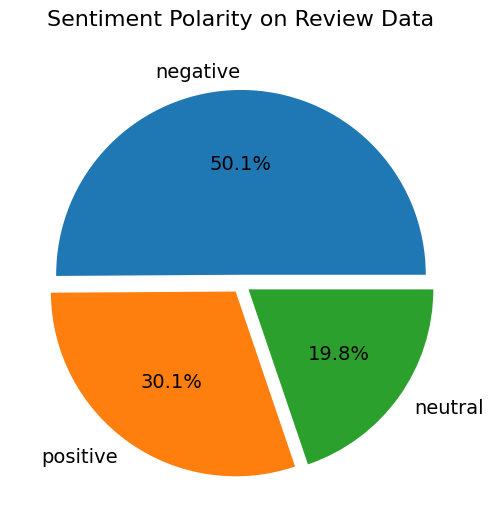

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
sizes = [count for count in clean_df['polarity'].value_counts()]
labels = list(clean_df['polarity'].value_counts().index)
explode = (0.1, 0)

ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', explode= [0.05] * len(sizes), textprops={'fontsize': 14})
ax.set_title('Sentiment Polarity on Review Data', fontsize=16, pad=20)
plt.show()

In [19]:
pd.set_option('display.max_colwidth', 3000)

positive_reviews = clean_df[clean_df['polarity'] == 'positive']

positive_reviews = positive_reviews[['text_akhir', 'polarity_score', 'polarity','text_stopword']]

positive_reviews = positive_reviews.sort_values(by='polarity_score', ascending=False)

positive_reviews = positive_reviews.reset_index(drop=True)

positive_reviews.index += 1

In [20]:
pd.set_option('display.max_colwidth', 3000)

negative_reviews = clean_df[clean_df['polarity'] == 'negative']

negative_reviews = negative_reviews[['text_akhir', 'polarity_score', 'polarity','text_stopword']]

negative_reviews = negative_reviews.sort_values(by='polarity_score', ascending=True)

negative_reviews = negative_reviews[0:10]

negative_reviews = negative_reviews.reset_index(drop=True)

negative_reviews.index += 1

In [21]:
pd.set_option('display.max_colwidth', 3000)

neutral_reviews = clean_df[clean_df['polarity'] == 'neutral']

neutral_reviews = neutral_reviews[['text_akhir', 'polarity_score', 'polarity', 'text_stopword']]

neutral_reviews = neutral_reviews.sort_values(by='polarity_score', ascending=False)

neutral_reviews = neutral_reviews.reset_index(drop=True)

neutral_reviews.index += 1

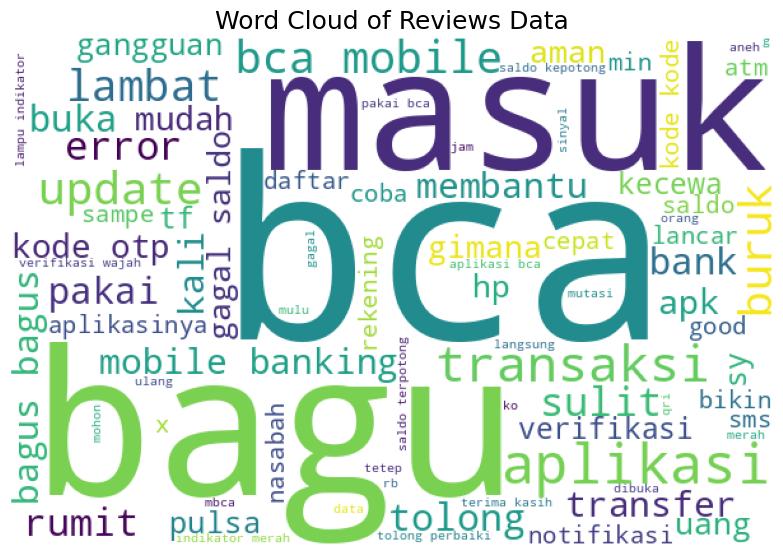

In [22]:
list_words = ''

for tweet in clean_df['text_stopword']:
    for word in tweet:
        list_words += ' ' + (word)

wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

fig, ax = plt.subplots(figsize=(8, 6))

ax.set_title('Word Cloud of Reviews Data', fontsize=18)

ax.grid(False)

ax.imshow((wordcloud))

fig.tight_layout(pad=0)

ax.axis('off')

plt.show()

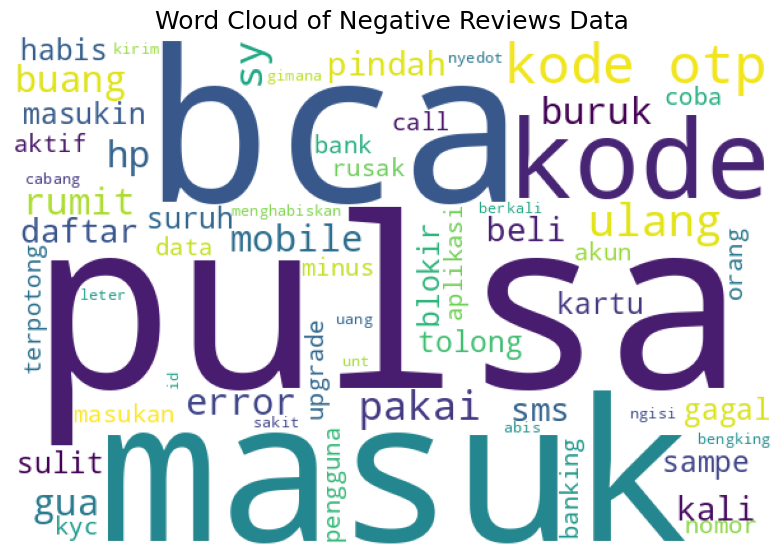

In [23]:
list_words = ''

for review in negative_reviews['text_stopword']:
    for word in review:
        list_words += ' ' + (word)

wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud of Negative Reviews Data', fontsize=18)
ax.grid(False)
ax.imshow((wordcloud))
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()

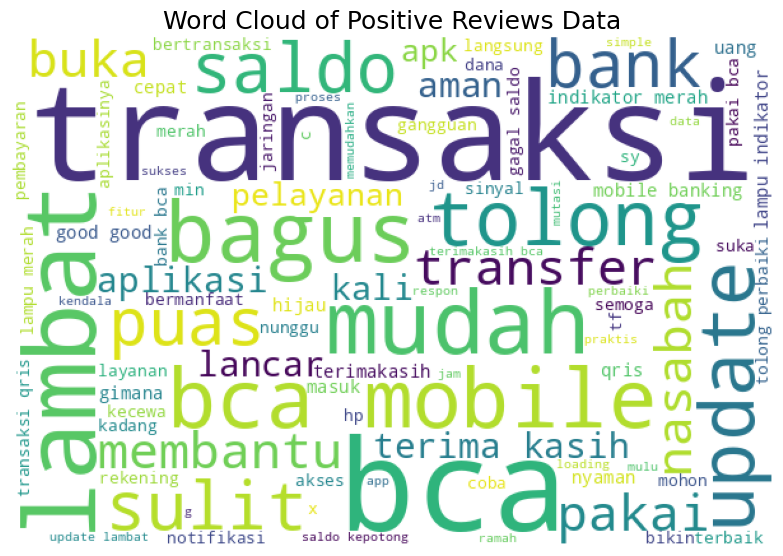

In [24]:
list_words = ''

for review in positive_reviews['text_stopword']:
    for word in review:
        list_words += ' ' + (word)

wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud of Positive Reviews Data', fontsize=18)
ax.grid(False)
ax.imshow((wordcloud))
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()

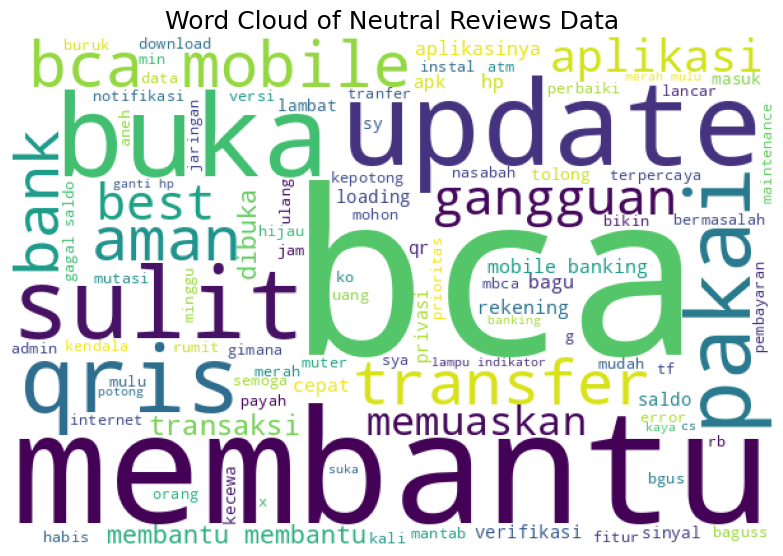

In [25]:
list_words = ''

for review in neutral_reviews['text_stopword']:
    for word in review:
        list_words += ' ' + (word)

wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Word Cloud of Neutral Reviews Data', fontsize=18)
ax.grid(False)
ax.imshow((wordcloud))
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()

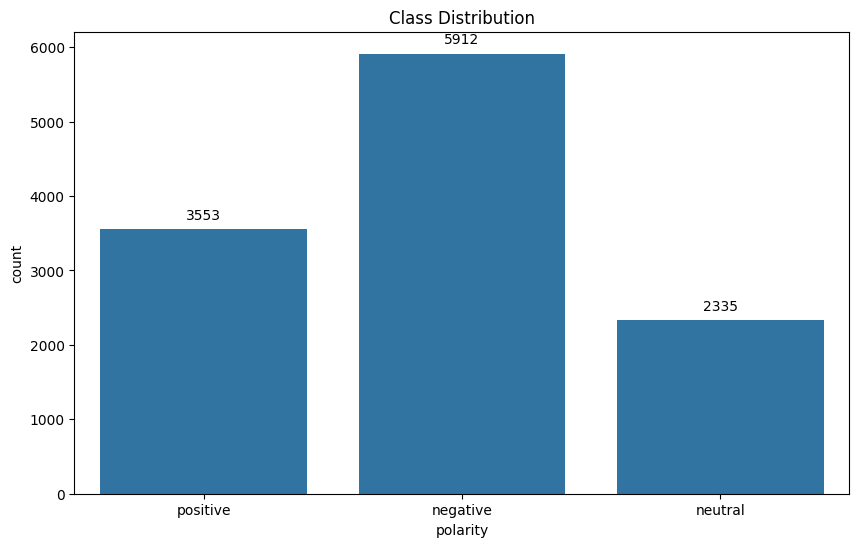

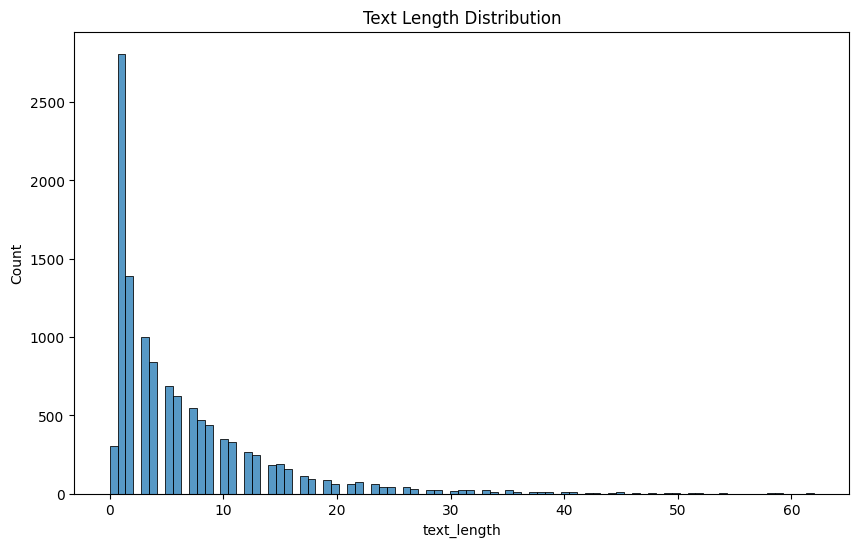

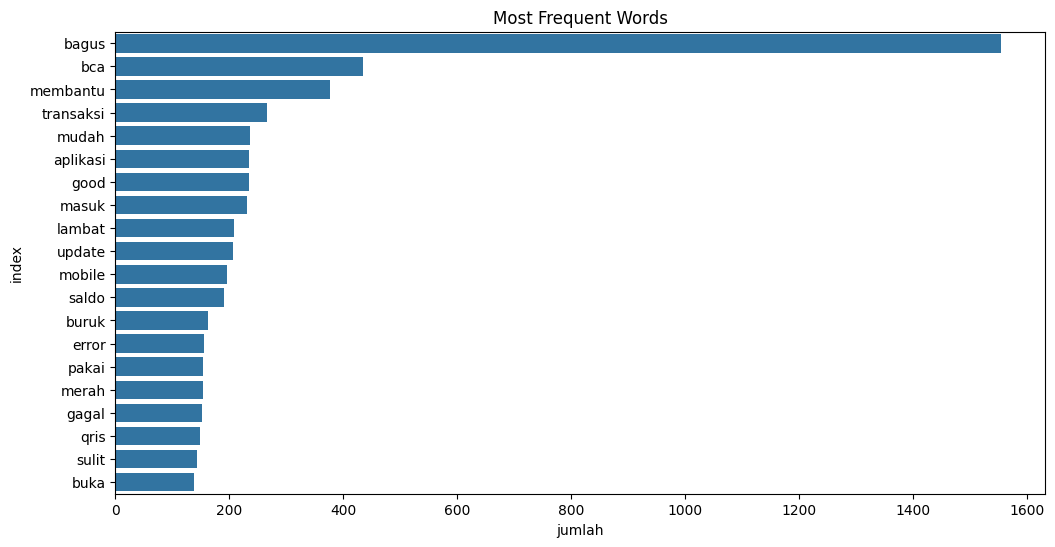

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

plt.figure(figsize=(10, 6))

class_dist_plot = sns.countplot(x='polarity', data=clean_df)
plt.title('Class Distribution')

for p in class_dist_plot.patches:
    class_dist_plot.annotate(format(p.get_height(), '.0f'),
                              (p.get_x() + p.get_width() / 2., p.get_height()),
                              ha='center', va='center',
                              xytext=(0, 10),
                              textcoords='offset points')

plt.show()

plt.figure(figsize=(10, 6))

clean_df['text_length'] = clean_df['text_akhir'].apply(lambda x: len(x.split()))
sns.histplot(clean_df['text_length'])
plt.title('Text Length Distribution')
plt.show()

plt.figure(figsize=(12, 6))

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(clean_df['text_akhir'])
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df = tfidf_df.sum().reset_index(name='jumlah')
tfidf_df = tfidf_df.sort_values('jumlah', ascending=False).head(20)
sns.barplot(x='jumlah', y='index', data=tfidf_df)
plt.title('Most Frequent Words')
plt.show()

In [27]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score, precision_score

In [28]:
clean_df.head(2)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir,polarity_score,polarity,text_length
0,0321d976-0cc8-4143-9f05-7574651dab78,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"knp ya akhir"" ini Qris BCA susah di akses. loading banget ga muncul"" barcode nya. ga bisa di ajak buru"". alhasil pake akun bank yg lain. padahal peruntukannya beda. Tolong diperbaiki lagi ya.. trimakasih",4,0,4.7.9,2026-03-30 05:08:15,"Mohon maaf atas kendala yang Bapak/Ibu alami. Untuk mengakses m-BCA pada aplikasi BCA mobile mohon dipastikan nomor HP m-BCA berada pada slot SIM 1, menggunakan jaringan internet dari nomor HP m-BCA yang terdaftar, memiliki ketersediaan pulsa yang cukup serta tidak menggunakan WiFi.\n",2026-03-30 05:25:34,4.7.9,knp ya akhir ini Qris BCA susah di akses loading banget ga muncul barcode nya ga bisa di ajak buru alhasil pake akun bank yg lain padahal peruntukannya beda Tolong diperbaiki lagi ya trimakasih,knp ya akhir ini qris bca susah di akses loading banget ga muncul barcode nya ga bisa di ajak buru alhasil pake akun bank yg lain padahal peruntukannya beda tolong diperbaiki lagi ya trimakasih,kenapa ya akhir ini qris bca sulit di akses loading sangat tidak muncul barcode nya tidak bisa di ajak buru alhasil pakai akun bank yang lain padahal peruntukannya beda tolong diperbaiki lagi ya trimakasih,"[kenapa, ya, akhir, ini, qris, bca, sulit, di, akses, loading, sangat, tidak, muncul, barcode, nya, tidak, bisa, di, ajak, buru, alhasil, pakai, akun, bank, yang, lain, padahal, peruntukannya, beda, tolong, diperbaiki, lagi, ya, trimakasih]","[qris, bca, sulit, akses, loading, muncul, barcode, ajak, buru, alhasil, pakai, akun, bank, peruntukannya, beda, tolong, diperbaiki, trimakasih]",qris bca sulit akses loading muncul barcode ajak buru alhasil pakai akun bank peruntukannya beda tolong diperbaiki trimakasih,2,positive,18
1,a292b0aa-418a-400f-89b2-1672154c2d61,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"kenapa kok sering merah indikator nya , dan itu lama bgt jd kl mau dibuat transaksi gak bisa. SUDAH DI RESTART juga masih tetap belum bisa, sampai kl mau bayar Qris atau tf di depan org nya sampek malu, hp bolak2 di restart , kayak nggak ngerti teknologi.",1,0,4.7.9,2026-03-30 04:59:48,"Mohon maaf atas kendala yang Bapak/Ibu alami. Untuk mengakses m-BCA pada aplikasi BCA mobile mohon dipastikan nomor HP m-BCA berada pada slot SIM 1, menggunakan jaringan internet dari nomor HP m-BCA yang terdaftar, memiliki ketersediaan pulsa yang cukup serta tidak menggunakan WiFi.\n",2026-03-30 05:27:50,4.7.9,kenapa kok sering merah indikator nya dan itu lama bgt jd kl mau dibuat transaksi gak bisa SUDAH DI RESTAjuga masih tetap belum bisa sampai kl mau bayar Qris atau tf di depan org nya sampek malu hp bolak di restart kayak nggak ngerti teknologi,kenapa kok sering merah indikator nya dan itu lama bgt jd kl mau dibuat transaksi gak bisa sudah di restajuga masih tetap belum bisa sampai kl mau bayar qris atau tf di depan org nya sampek malu hp bolak di restart kayak nggak ngerti teknologi,kenapa kok sering merah indikator nya dan itu lama sangat jd kalau mau dibuat transaksi tidak bisa sudah di restajuga masih tetap belum bisa sampai kalau mau bayar qris atau tf di depan org nya sampek malu hp bolak di restart kayak tidak ngerti teknologi,"[kenapa, kok, sering, merah, indikator, nya, dan, itu, lama, sangat, jd, kalau, mau, dibuat, transaksi, tidak, bisa, sudah, di, restajuga, masih, tetap, belum, bisa, sampai, kalau, mau, bayar, qris, atau, tf, di, depan, org, nya, sampek, malu, hp, bolak, di, restart, kayak, tidak, ngerti, teknologi]","[merah, indikator, jd, transaksi, restajuga, bayar, qris, tf, org, sampek, mal

In [29]:
X = clean_df['text_akhir']
y = clean_df['polarity']

In [30]:
!pip install tensorflow gensim imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 23.9 MB/s eta 0:00:00


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Distribusi awal:")
print(clean_df['polarity'].value_counts())

X_text_raw    = clean_df['text_akhir'].astype(str)
y_raw         = clean_df['polarity']

le_smote      = LabelEncoder()
y_encoded_raw = le_smote.fit_transform(y_raw)

tfidf_smote   = TfidfVectorizer(max_features=3000)
X_tfidf_raw   = tfidf_smote.fit_transform(X_text_raw).toarray()

print(f"Distribusi sebelum SMOTE : {Counter(y_encoded_raw)}")

smote         = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_tfidf_raw, y_encoded_raw)

print(f"Distribusi setelah SMOTE : {Counter(y_smote)}")

y_smote_labels    = le_smote.inverse_transform(y_smote)
X_smote_text      = tfidf_smote.inverse_transform(X_smote)
X_smote_text_joined = [' '.join(words) for words in X_smote_text]

df_balanced = pd.DataFrame({
    'text_akhir' : X_smote_text_joined,
    'polarity'   : y_smote_labels
}).sample(frac=1, random_state=42).reset_index(drop=True)

print("\nDistribusi df_balanced setelah SMOTE:")
print(df_balanced['polarity'].value_counts())

Distribusi awal:
polarity
negative    5912
positive    3553
neutral     2335
Name: count, dtype: int64
Distribusi sebelum SMOTE : Counter({np.int64(0): 5912, np.int64(2): 3553, np.int64(1): 2335})
Distribusi setelah SMOTE : Counter({np.int64(2): 5912, np.int64(0): 5912, np.int64(1): 5912})

Distribusi df_balanced setelah SMOTE:
polarity
neutral     5912
negative    5912
positive    5912
Name: count, dtype: int64


## Percobaan Skema 1
- Pelatihan: LSTM
- Ekstraksi Fitur: TF-IDF
- Pembagian Data: 80/20

In [32]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.utils import to_categorical

X_text = df_balanced['text_akhir'].astype(str)
y_label = df_balanced['polarity']

le = LabelEncoder()
y_encoded = le.fit_transform(y_label)
y_categorical = to_categorical(y_encoded)

tfidf = TfidfVectorizer(max_features=3000)
X_tfidf = tfidf.fit_transform(X_text).toarray()

X_lstm = np.reshape(X_tfidf, (X_tfidf.shape[0], 1, X_tfidf.shape[1]))

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X_lstm, y_categorical, test_size=0.2, random_state=42)

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

model = Sequential()

model.add(LSTM(32, input_shape=(X_train.shape[1], X_train.shape[2]),
               kernel_regularizer=l2(0.01)))
model.add(Dropout(0.5))

model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dropout(0.5))

model.add(Dense(y_categorical.shape[1], activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


print("Memulai pelatihan model LSTM")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Memulai pelatihan model LSTM
Epoch 1/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.4850 - loss: 1.2064 - val_accuracy: 0.5778 - val_loss: 1.0344
Epoch 2/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5623 - loss: 0.9912 - val_accuracy: 0.5651 - val_loss: 0.9279
Epoch 3/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6339 - loss: 0.9259 - val_accuracy: 0.6277 - val_loss: 0.8622
Epoch 4/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6977 - loss: 0.8723 - val_accuracy: 0.8410 - val_loss: 0.7998
Epoch 5/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7546 - loss: 0.8281 - val_accuracy: 0.8667 - val_loss: 0.7578
Epoch 6/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7870 - loss: 0.7942 - val_accuracy: 0.8830 - val_loss: 0.7045
Epoch 7/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8086 - loss: 0.7682 - val_accuracy: 0.8909 - val_loss: 0.6731
Epoch 8/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8209 

In [35]:
train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
print(f"Akurasi Train : {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Akurasi Test  : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

Akurasi Train : 0.9471 (94.71%)
Akurasi Test  : 0.9104 (91.04%)


## Percobaan Skema 2
- Pelatihan: GRU
- Ekstraksi Fitur: TF-IDF
- Pembagian Data: 80/20

In [36]:
!pip install gensim

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
from collections import Counter

X_text_tfidf = clean_df['text_akhir'].astype(str)
y_raw_tfidf  = clean_df['polarity']

le_gru_tfidf   = LabelEncoder()
y_enc_tfidf    = le_gru_tfidf.fit_transform(y_raw_tfidf)
print(f"Distribusi sebelum SMOTE : {Counter(y_enc_tfidf)}")

tfidf_gru      = TfidfVectorizer(max_features=3000)
X_tfidf_gru    = tfidf_gru.fit_transform(X_text_tfidf).toarray()
print(f"Shape TF-IDF             : {X_tfidf_gru.shape}")

smote_gru                    = SMOTE(random_state=42)
X_smote_gru, y_smote_gru     = smote_gru.fit_resample(X_tfidf_gru, y_enc_tfidf)
print(f"Distribusi setelah SMOTE : {Counter(y_smote_gru)}")
print(f"Shape setelah SMOTE      : {X_smote_gru.shape}")

y_smote_cat_gru = to_categorical(y_smote_gru)

X_smote_gru_3d = X_smote_gru.reshape(X_smote_gru.shape[0], 1, X_smote_gru.shape[1])
print(f"Shape setelah reshape 3D : {X_smote_gru_3d.shape}")

X_train_gru_tf, X_test_gru_tf, y_train_gru_tf, y_test_gru_tf = train_test_split(
    X_smote_gru_3d, y_smote_cat_gru,
    test_size=0.2,
    random_state=42,
    stratify=y_smote_gru
)

print(f"\nTrain : {X_train_gru_tf.shape}")
print(f"Test  : {X_test_gru_tf.shape}")

Distribusi sebelum SMOTE : Counter({np.int64(0): 5912, np.int64(2): 3553, np.int64(1): 2335})
Shape TF-IDF             : (11800, 3000)
Distribusi setelah SMOTE : Counter({np.int64(2): 5912, np.int64(0): 5912, np.int64(1): 5912})
Shape setelah SMOTE      : (17736, 3000)
Shape setelah reshape 3D : (17736, 1, 3000)

Train : (14188, 1, 3000)
Test  : (3548, 1, 3000)


In [38]:
from tensorflow.keras.regularizers import l2

model_gru_tf = Sequential([

    GRU(64,
        input_shape=(1, 3000),
        dropout=0.4,
        recurrent_dropout=0.2,
        kernel_regularizer=l2(0.01)),

    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.4),

    Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [39]:
model_gru_tf.summary()

model_gru_tf.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

early_stopping_gru_tf = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("Memulai pelatihan GRU + TF-IDF + SMOTE.")
history_gru_tf = model_gru_tf.fit(
    X_train_gru_tf, y_train_gru_tf,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_gru_tf, y_test_gru_tf),
    callbacks=[early_stopping_gru_tf]
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │       588,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 590,851 (2.25 MB)

 Trainable params: 590,851 (2.25 MB)

 Non-trainable params: 0 (0.00 B)

Memulai pelatihan GRU + TF-IDF + SMOTE.
Epoch 1/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - accuracy: 0.5660 - loss: 1.2136 - val_accuracy: 0.7982 - val_loss: 0.9056
Epoch 2/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.6725 - loss: 0.9516 - val_accuracy: 0.8323 - val_loss: 0.7908
Epoch 3/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.6861 - loss: 0.9214 - val_accuracy: 0.8337 - val_loss: 0.7545
Epoch 4/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.6966 - loss: 0.8925 - val_accuracy: 0.8436 - val_loss: 0.7219
Epoch 5/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.7100 - loss: 0.8646 - val_accuracy: 0.8689 - val_loss: 0.6876
Epoch 6/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.7112 - loss: 0.8516 - val_accuracy: 0.8529 - val_loss: 0.6710
Epoch 7/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.7142 - loss: 0.8370 - val_accuracy: 0.8763 - val_loss: 0.6579
Epoch 8/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/s

In [40]:
print("--- Evaluasi Model GRU + TF-IDF ---")
train_loss_gru_tf, train_acc_gru_tf = model_gru_tf.evaluate(
    X_train_gru_tf, y_train_gru_tf, verbose=0)
print(f"Akurasi Train : {train_acc_gru_tf:.4f} ({train_acc_gru_tf*100:.2f}%)")

test_loss_gru_tf, test_acc_gru_tf = model_gru_tf.evaluate(
    X_test_gru_tf, y_test_gru_tf, verbose=0)
print(f"Akurasi Test  : {test_acc_gru_tf:.4f} ({test_acc_gru_tf*100:.2f}%)")

--- Evaluasi Model GRU + TF-IDF ---
Akurasi Train : 0.9368 (93.68%)
Akurasi Test  : 0.8980 (89.80%)


## Percobaan Skema 3
- Pelatihan: CNN
- Ekstraksi Fitur: FastText
- Pembagian Data: 80/20

In [41]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from gensim.models import FastText

X_text = df_balanced['text_akhir'].astype(str).tolist()
y_label = df_balanced['polarity']

le = LabelEncoder()
y_encoded = le.fit_transform(y_label)
y_categorical = to_categorical(y_encoded)

sentences = [text.split() for text in X_text]

print("Melatih model FastText.")
ft_model = FastText(sentences, vector_size=100, window=5, min_count=2, workers=4)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_text)
X_seq = tokenizer.texts_to_sequences(X_text)

MAX_LENGTH = 50
X_pad = pad_sequences(X_seq, maxlen=MAX_LENGTH, padding='post')
vocab_size = len(tokenizer.word_index) + 1

embedding_matrix = np.zeros((vocab_size, 100))
for word, i in tokenizer.word_index.items():

    try:
        embedding_matrix[i] = ft_model.wv[word]
    except KeyError:
        pass

Melatih model FastText.


In [42]:
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(X_pad, y_categorical, test_size=0.2, random_state=42)

In [43]:
print(f"Ukuran data train : {X_train_cnn.shape}")
print(f"Ukuran data test  : {X_test_cnn.shape}")

Ukuran data train : (14188, 50)
Ukuran data test  : (3548, 50)


In [44]:
from tensorflow.keras.layers import (
    Embedding, Conv1D, GlobalMaxPooling1D,
    Dense, Dropout
)

early_stopping_cnn = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_cnn = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=100,
        weights=[embedding_matrix],
        input_length=MAX_LENGTH,
        trainable=True
    ),

    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(y_categorical.shape[1], activation='softmax')
])

model_cnn.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [45]:
model_cnn.summary()

print("\nMemulai pelatihan model CNN + FastText.")
history_cnn = model_cnn.fit(
    X_train_cnn, y_train_cnn,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_cnn, y_test_cnn),
    callbacks=[early_stopping_cnn]
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │       300,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 300,100 (1.14 MB)

 Trainable params: 300,100 (1.14 MB)

 Non-trainable params: 0 (0.00 B)


Memulai pelatihan model CNN + FastText.
Epoch 1/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.6833 - loss: 0.7050 - val_accuracy: 0.8551 - val_loss: 0.3699
Epoch 2/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.8806 - loss: 0.3439 - val_accuracy: 0.8873 - val_loss: 0.2883
Epoch 3/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9197 - loss: 0.2330 - val_accuracy: 0.9143 - val_loss: 0.2233
Epoch 4/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9388 - loss: 0.1738 - val_accuracy: 0.9225 - val_loss: 0.1983
Epoch 5/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9518 - loss: 0.1360 - val_accuracy: 0.9366 - val_loss: 0.1982
Epoch 6/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9626 - loss: 0.1103 - val_accuracy: 0.9408 - val_loss: 0.1991
Epoch 7/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9684 - loss: 0.0961 - val_accuracy: 0.9425 - val_loss: 0.2068
Epoch 8/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step -

In [46]:
print("--- Evaluasi Model CNN + FastText ---")
train_loss_cnn, train_accuracy_cnn = model_cnn.evaluate(X_train_cnn, y_train_cnn, verbose=0)
print(f"Akurasi Train : {train_accuracy_cnn:.4f} ({train_accuracy_cnn*100:.2f}%)")

test_loss_cnn, test_accuracy_cnn = model_cnn.evaluate(X_test_cnn, y_test_cnn, verbose=0)
print(f"Akurasi Test  : {test_accuracy_cnn:.4f} ({test_accuracy_cnn*100:.2f}%)")

--- Evaluasi Model CNN + FastText ---
Akurasi Train : 0.9746 (97.46%)
Akurasi Test  : 0.9366 (93.66%)


# Save Model

In [47]:
import pickle

model.save('model_lstm.h5')
model_gru_tf.save('model_gru.h5')
model_cnn.save('model_cnn.h5')

with open('tfidf_lstm.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open('tfidf_gru.pkl', 'wb') as f:
    pickle.dump(tfidf_gru, f)

with open('tokenizer_cnn.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Semua file tersimpan")

Semua file tersimpan


In [48]:
pip freeze requirements.txt

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.12.1
anywidget==0.9.21
apsw==3.51.3.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.3.16.0.53.33
astunparse==1.6.3
atpublic==5.1
attrs==25.4.0
audioread==3.1.0
Authlib==1.6.9
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.38.0
bigquery-magics==0.10.3
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.1.2
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.2.25
c